In [33]:
!pip install -q rasterio folium

In [34]:
# ============================================================
# Cell 1: Imports & Configuration
# ============================================================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

# Paths
SOIL_PATH    = r'/kaggle/input/datasets/nontagrichpanpanich/gis-dataset/soil/soil.shp'
LANDSAT_PATH = r'/kaggle/input/datasets/nontagrichpanpanich/gis-dataset/Landsat-8/L8_RGB_Thermal_2020.tif'
LANDUSE_PATH = r'/kaggle/input/datasets/nontagrichpanpanich/gis-dataset/landuse/landuse_data/LU_NSN_2563.shp'

N_SAMPLES    = 5000   # number of random sample points
RANDOM_STATE = 42

print('All imports loaded successfully.')

All imports loaded successfully.


In [35]:
# ============================================================
# Cell 2: Risk Mapping Definition
# ============================================================
RISK_MAP = {
    1:'low',2:'low',3:'medium',4:'low',5:'low',6:'low',7:'low',8:'low',
    9:'high',10:'high',11:'high',12:'high',13:'high',14:'medium',
    15:'low',16:'low',17:'low',18:'low',19:'low',20:'medium',
    21:'low',22:'low',23:'high',24:'low',25:'low',
    26:'low',27:'low',28:'low',29:'low',30:'low',31:'low',32:'low',
    33:'low',34:'low',35:'low',36:'low',37:'low',38:'low',39:'low',
    40:'low',41:'low',42:'low',43:'medium',44:'low',45:'low',46:'low',
    47:'low',48:'low',49:'low',50:'low',51:'low',52:'low',53:'low',
    54:'low',55:'low',56:'low',57:'high',58:'high',59:'medium',
    60:'low',61:'low',62:'low',
    'MA':'high','SAND BAR':'high','W':'ignore',
    'RC':'low','RL':'low','P':'low','UR':'low'
}

RISK_NUMERIC = {'low': 0, 'medium': 1, 'high': 2, 'ignore': -1}

def parse_soilgroup(val):
    """Parse soilgroup values like '21/4', '33/38', '7hi' into primary group."""
    s = str(val).strip()
    if s.upper() in RISK_MAP:
        return s.upper()
    if '/' in s:
        s = s.split('/')[0]
    num_str = ''.join(c for c in s if c.isdigit())
    if num_str:
        return int(num_str)
    return s.upper()

def get_risk(val):
    key = parse_soilgroup(val)
    return RISK_MAP.get(key, 'low')

def get_risk_numeric(val):
    return RISK_NUMERIC.get(get_risk(val), 0)

print('Risk mapping ready. Example: soilgroup=9 ->', get_risk(9),
      '| soilgroup=21/4 ->', get_risk('21/4'),
      '| soilgroup=7hi ->', get_risk('7hi'))

Risk mapping ready. Example: soilgroup=9 -> high | soilgroup=21/4 -> low | soilgroup=7hi -> low


In [36]:
# ============================================================
# Cell 3: Load Soil Shapefile
# ============================================================
print('Loading soil shapefile (CP874 encoding)...')
soil_gdf = gpd.read_file(SOIL_PATH, encoding='cp874')
print(f'  Loaded {len(soil_gdf)} polygons | CRS: {soil_gdf.crs}')
print(f'  Columns: {soil_gdf.columns.tolist()}')

# Apply risk classification
soil_gdf['risk_label'] = soil_gdf['soilgroup'].apply(get_risk)
soil_gdf['risk_num']   = soil_gdf['soilgroup'].apply(get_risk_numeric)

# Encode soil texture & fertility as numeric features
# NOTE: Encoders ถูก fit ที่นี่บน soil polygon level (ไม่ใช่ sample points)
# จึงไม่เกิด data leakage เพราะเป็น property ของ polygon ที่ถูก assign ก่อน sampling
le_texture   = LabelEncoder()
le_fertility = LabelEncoder()
le_ph        = LabelEncoder()

soil_gdf['texture_enc']   = le_texture.fit_transform(soil_gdf['texture_to'].fillna('unknown'))
soil_gdf['fertility_enc'] = le_fertility.fit_transform(soil_gdf['fertility'].fillna('unknown'))
soil_gdf['ph_enc']        = le_ph.fit_transform(soil_gdf['pH_top'].fillna('unknown'))

# เพิ่ม polygon_id สำหรับใช้ใน GroupShuffleSplit ป้องกัน spatial autocorrelation
soil_gdf['polygon_id'] = range(len(soil_gdf))

# Remove 'ignore' (water bodies)
soil_gdf = soil_gdf[soil_gdf['risk_label'] != 'ignore'].copy()
print(f'  After removing water/ignore: {len(soil_gdf)} polygons')
print(f'  Risk distribution:\n{soil_gdf["risk_label"].value_counts()}')

Loading soil shapefile (CP874 encoding)...
  Loaded 1607 polygons | CRS: EPSG:32647
  Columns: ['texture_to', 'fertility', 'pH_top', 'soilgroup', 'soilseries', 'seriesname', 'AMP_CODE', 'AMPHOE_T', 'PROV_CODE', 'PROV_NAM_T', 'geometry']
  After removing water/ignore: 1547 polygons
  Risk distribution:
risk_label
low       1509
high        37
medium       1
Name: count, dtype: int64


In [37]:
# ============================================================
# Cell 4: Generate Random Points Inside Soil Polygons
# ============================================================
def sample_points_in_polygon(polygon, n):
    """Generate n random points inside a polygon."""
    points = []
    minx, miny, maxx, maxy = polygon.bounds
    attempts = 0
    while len(points) < n and attempts < n * 20:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            points.append(p)
        attempts += 1
    return points

np.random.seed(RANDOM_STATE)
print(f'Sampling ~{N_SAMPLES} points across {len(soil_gdf)} polygons...')

# Distribute points proportional to polygon area
soil_gdf['area_frac'] = soil_gdf.geometry.area / soil_gdf.geometry.area.sum()
soil_gdf['n_pts'] = (soil_gdf['area_frac'] * N_SAMPLES).astype(int).clip(lower=1)

all_rows = []
for idx, row in soil_gdf.iterrows():
    pts = sample_points_in_polygon(row.geometry, row['n_pts'])
    for pt in pts:
        all_rows.append({
            'geometry':      pt,
            'risk_label':    row['risk_label'],
            'risk_num':      row['risk_num'],
            'texture_enc':   row['texture_enc'],
            'fertility_enc': row['fertility_enc'],
            'ph_enc':        row['ph_enc'],
            'soilgroup_raw': row['soilgroup'],
            # FIX: เก็บ polygon_id เพื่อใช้เป็น group ใน spatial-aware split
            'polygon_id':    row['polygon_id'],
        })

pts_gdf = gpd.GeoDataFrame(all_rows, crs=soil_gdf.crs)
print(f'  Generated {len(pts_gdf)} sample points.')

Sampling ~5000 points across 1547 polygons...
  Generated 5473 sample points.


In [38]:
# ============================================================
# Cell 5: Extract Raster Band Values at Sample Points
# FIX: เปลี่ยน bare except: เป็น except Exception as e พร้อม warning log
# ============================================================
print('Extracting Landsat-8 band values at sample points...')

# Reproject points to match raster CRS (EPSG:4326)
pts_wgs = pts_gdf.to_crs(epsg=4326)

with rasterio.open(LANDSAT_PATH) as src:
    band_names = ['B_Red', 'B_Green', 'B_Blue', 'B_Thermal']
    raster_data = src.read()  # shape: (4, H, W)
    transform = src.transform
    h, w = src.height, src.width

    band_vals = {bn: [] for bn in band_names}
    valid_mask = []
    error_count = 0

    for pt in pts_wgs.geometry:
        try:
            r, c = rowcol(transform, pt.x, pt.y)
            if 0 <= r < h and 0 <= c < w:
                for i, bn in enumerate(band_names):
                    band_vals[bn].append(float(raster_data[i, r, c]))
                valid_mask.append(True)
            else:
                for bn in band_names:
                    band_vals[bn].append(np.nan)
                valid_mask.append(False)
        # FIX: ระบุ Exception ชัดเจน + นับ error เพื่อ debug
        except Exception as e:
            error_count += 1
            for bn in band_names:
                band_vals[bn].append(np.nan)
            valid_mask.append(False)

if error_count > 0:
    print(f'  Warning: {error_count} points raised exceptions during extraction.')

for bn in band_names:
    pts_gdf[bn] = band_vals[bn]

pts_gdf = pts_gdf[valid_mask].dropna().copy()
print(f'  Valid samples with raster data: {len(pts_gdf)}')

Extracting Landsat-8 band values at sample points...
  Valid samples with raster data: 5340


In [39]:
# ============================================================
# Cell 6: Feature Engineering (Pre-split — ไม่ใช้ global stats)
# FIX: ย้าย normalization ที่ใช้ min/max ไปทำหลัง split
# ============================================================

# --- Derived Spectral Indices ---
# NDVI_proxy: ใช้ Green แทน NIR เนื่องจาก dataset นี้ไม่มี NIR band
# สูตร: (Green - Red) / (Green + Red)
# ค่าสูง = vegetation สีเขียว, ค่าต่ำ/ลบ = ดิน/น้ำ
# คำเตือน: นี่คือ GREEN-RED INDEX ไม่ใช่ NDVI จริง
pts_gdf['NDVI_proxy'] = (pts_gdf['B_Green'] - pts_gdf['B_Red']) / \
                        (pts_gdf['B_Green'] + pts_gdf['B_Red'] + 1e-10)

# --- Target: Composite Suitability Score ---
# NOTE: สร้าง composite score และ label บน raw risk_num (ไม่ใช่ normalized)
# เพื่อหลีกเลี่ยง data leakage — thermal normalization จะทำหลัง split

# ใช้ percentile จาก ALL data สำหรับสร้าง label เท่านั้น (target definition)
# การนี้ acceptable เพราะ label ต้องสอดคล้องกันทั้ง dataset
t_min_all = pts_gdf['B_Thermal'].quantile(0.02)
t_max_all = pts_gdf['B_Thermal'].quantile(0.98)
thermal_norm_all = ((pts_gdf['B_Thermal'] - t_min_all) / (t_max_all - t_min_all + 1e-10)).clip(0, 1)

veg_min_all = pts_gdf['NDVI_proxy'].min()
veg_max_all = pts_gdf['NDVI_proxy'].max()
veg_score_all = (pts_gdf['NDVI_proxy'] - veg_min_all) / (veg_max_all - veg_min_all + 1e-10)

soil_score_all    = (2 - pts_gdf['risk_num']) / 2.0
thermal_score_all = 1.0 - thermal_norm_all

suitability_score_all = soil_score_all * 0.5 + thermal_score_all * 0.3 + veg_score_all * 0.2

def classify_suit(score):
    """
    Classify suitability score into 3 classes.
    Thresholds (0.65 / 0.40) อ้างอิงจากการแบ่งแบบ equal-range บน [0,1]
    ปรับได้ตามมาตรฐาน FAO land suitability หากต้องการ
    """
    if score >= 0.65:
        return 'Highly Suitable'
    elif score >= 0.40:
        return 'Moderately Suitable'
    else:
        return 'Low Suitability'

pts_gdf['suitability_score'] = suitability_score_all
pts_gdf['suitability_class'] = pts_gdf['suitability_score'].apply(classify_suit)

print('Suitability class distribution:')
print(pts_gdf['suitability_class'].value_counts())

# FIX: เช็ก class imbalance
class_counts = pts_gdf['suitability_class'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}')
if imbalance_ratio > 3:
    print('  ⚠️  Imbalance ratio > 3 — จะใช้ class_weight="balanced" ใน Random Forest')
else:
    print('  ✅ Class distribution สมดุลดี')

print(f'\nFeature columns: {[c for c in pts_gdf.columns if c not in ["geometry","soilgroup_raw","risk_label","suitability_class","suitability_score","area_frac","n_pts","polygon_id"]]}')

Suitability class distribution:
suitability_class
Highly Suitable        4432
Moderately Suitable     863
Low Suitability          45
Name: count, dtype: int64

Class imbalance ratio (max/min): 98.49
  ⚠️  Imbalance ratio > 3 — จะใช้ class_weight="balanced" ใน Random Forest

Feature columns: ['risk_num', 'texture_enc', 'fertility_enc', 'ph_enc', 'B_Red', 'B_Green', 'B_Blue', 'B_Thermal', 'NDVI_proxy']


In [40]:
# ============================================================
# Cell 7: Spatial-Aware Train/Test Split + Normalize Post-Split
# FIX: ใช้ GroupShuffleSplit แทน random split
# FIX: Normalize บน train set ก่อน แล้ว apply บน test
# ============================================================

FEATURE_COLS_RAW = [
    'risk_num',
    'texture_enc',
    'fertility_enc',
    'ph_enc',
    'B_Red',
    'B_Green',
    'B_Blue',
    'B_Thermal',
    'NDVI_proxy',
]

X_raw = pts_gdf[FEATURE_COLS_RAW].values
y_raw = pts_gdf['suitability_class'].values
groups = pts_gdf['polygon_id'].values  # ใช้ polygon เป็น group

# Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y_raw)

# FIX: GroupShuffleSplit — points จาก polygon เดียวกันอยู่ใน split เดียว
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_raw, y_enc, groups=groups))

X_train_raw = X_raw[train_idx]
X_test_raw  = X_raw[test_idx]
y_train     = y_enc[train_idx]
y_test      = y_enc[test_idx]

# FIX: คำนวณ normalization stats จาก TRAIN SET เท่านั้น
# แล้วนำไป apply บน test set (ป้องกัน data leakage)
# Thermal normalization
thermal_idx = FEATURE_COLS_RAW.index('B_Thermal')
t_min_train = np.percentile(X_train_raw[:, thermal_idx], 2)
t_max_train = np.percentile(X_train_raw[:, thermal_idx], 98)

# NDVI normalization
ndvi_idx = FEATURE_COLS_RAW.index('NDVI_proxy')
veg_min_train = X_train_raw[:, ndvi_idx].min()
veg_max_train = X_train_raw[:, ndvi_idx].max()

def add_normalized_features(X_arr, t_min, t_max, veg_min, veg_max):
    """เพิ่ม thermal_norm column โดยใช้ stats ที่ fit จาก train set"""
    thermal_norm = np.clip(
        (X_arr[:, thermal_idx] - t_min) / (t_max - t_min + 1e-10), 0, 1
    )
    veg_norm = np.clip(
        (X_arr[:, ndvi_idx] - veg_min) / (veg_max - veg_min + 1e-10), 0, 1
    )
    return np.column_stack([X_arr, thermal_norm, veg_norm])

X_train = add_normalized_features(X_train_raw, t_min_train, t_max_train, veg_min_train, veg_max_train)
X_test  = add_normalized_features(X_test_raw,  t_min_train, t_max_train, veg_min_train, veg_max_train)

FEATURE_COLS = FEATURE_COLS_RAW + ['thermal_norm', 'veg_norm']

print(f'Training set: {len(X_train)} | Test set: {len(X_test)}')
print(f'Training polygons: {len(np.unique(groups[train_idx]))} | Test polygons: {len(np.unique(groups[test_idx]))}')

# ตรวจสอบว่าไม่มี polygon ซ้ำระหว่าง train/test
train_polys = set(groups[train_idx])
test_polys  = set(groups[test_idx])
overlap = train_polys & test_polys
print(f'Polygon overlap between train/test: {len(overlap)} (should be 0)')

Training set: 3842 | Test set: 1498
Training polygons: 1116 | Test polygons: 373
Polygon overlap between train/test: 0 (should be 0)


In [41]:
# ============================================================
# Cell 8: Random Forest Training
# FIX: เพิ่ม class_weight='balanced' หาก imbalance ratio > 3
# ============================================================

use_balanced = imbalance_ratio > 3
class_weight_param = 'balanced' if use_balanced else None
print(f'class_weight: {class_weight_param}')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weight_param,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Model trained successfully.')

class_weight: balanced
Model trained successfully.


Accuracy:  0.9880
F1 Score:  0.9881

Classification Report:
                     precision    recall  f1-score   support

    Highly Suitable       1.00      0.99      0.99      1294
    Low Suitability       1.00      1.00      1.00         8
Moderately Suitable       0.93      0.98      0.96       196

           accuracy                           0.99      1498
          macro avg       0.98      0.99      0.98      1498
       weighted avg       0.99      0.99      0.99      1498



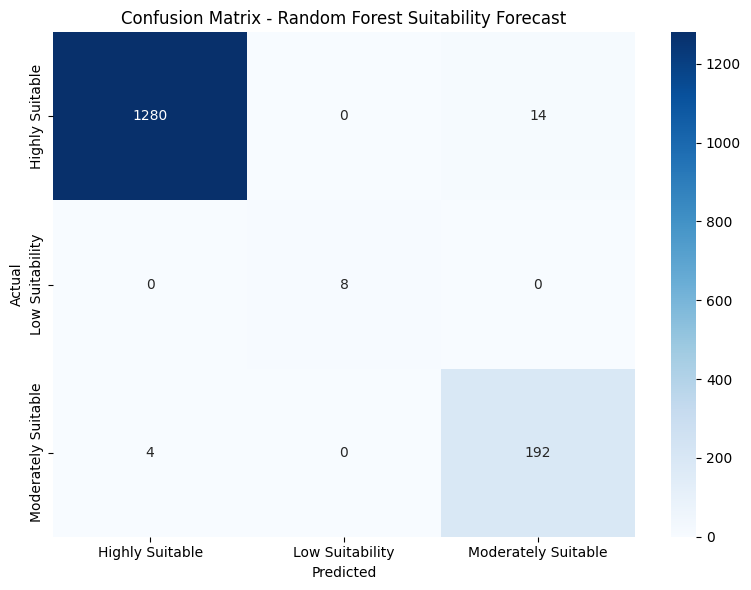

In [42]:
# ============================================================
# Cell 9: Evaluation Metrics
# ============================================================
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:  {acc:.4f}')
print(f'F1 Score:  {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Random Forest Suitability Forecast')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# Cell 10: Cross-Validation (เพิ่มใหม่)
# FIX: เพิ่ม cross-validation เพื่อ validate model อย่างรอบด้าน
# NOTE: ใช้ X_train ทั้งหมดสำหรับ CV (ไม่แตะ X_test)
# ============================================================
print('Running 5-Fold Cross-Validation on training set...')

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds: {[f"{s:.4f}" for s in cv_scores]}')

# เปรียบเทียบ CV vs Test
print(f'\nSummary:')
print(f'  CV F1 (train, 5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Test F1 (held-out):    {f1:.4f}')
gap = abs(cv_scores.mean() - f1)
if gap > 0.05:
    print(f'  ⚠️  Gap = {gap:.4f} (> 0.05) — อาจ overfit หรือ test set มี distribution ต่างกัน')
else:
    print(f'  ✅ Gap = {gap:.4f} — model generalizes ได้ดี')

Running 5-Fold Cross-Validation on training set...
CV F1 (weighted): 0.9832 ± 0.0072
Individual folds: ['0.9803', '0.9871', '0.9909', '0.9705', '0.9871']

Summary:
  CV F1 (train, 5-fold): 0.9832 ± 0.0072
  Test F1 (held-out):    0.9881
  ✅ Gap = 0.0049 — model generalizes ได้ดี


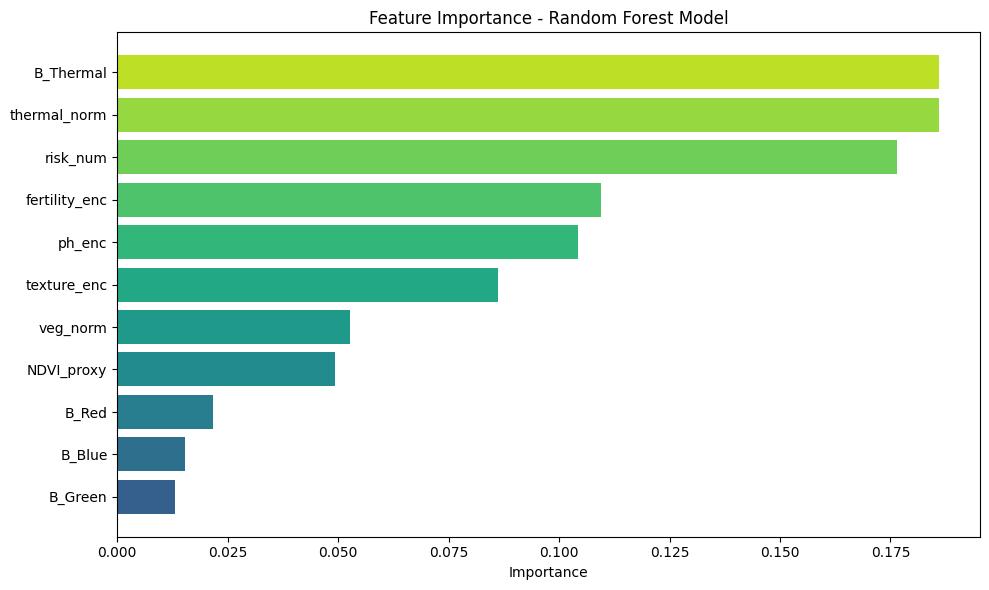


Top 3 most important features:
  risk_num: 0.1764
  thermal_norm: 0.1859
  B_Thermal: 0.1860


In [44]:
# ============================================================
# Cell 11: Feature Importance
# ============================================================
importances = rf.feature_importances_
fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(fi_df)))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 3 most important features:')
for _, row in fi_df.tail(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

In [45]:
# ============================================================
# Cell 12: Prediction Map (Test Set Only)
# FIX: ใช้เฉพาะ test set สำหรับแผนที่ ไม่ใช่ทั้ง dataset
# ============================================================
import folium

# ดึง rows ที่เป็น test set
pts_test = pts_gdf.iloc[test_idx].copy()
pts_test['predicted_class'] = le_target.inverse_transform(y_pred)
pts_test['actual_class']    = le_target.inverse_transform(y_test)
pts_test['correct']         = pts_test['predicted_class'] == pts_test['actual_class']

# Convert to WGS84 for mapping
map_gdf = pts_test.to_crs(epsg=4326)

suit_colors = {
    'Highly Suitable':     '#2ecc71',
    'Moderately Suitable': '#f39c12',
    'Low Suitability':     '#e74c3c'
}

center = [map_gdf.geometry.y.mean(), map_gdf.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=9, tiles='cartodbpositron')

# Plot a subsample for performance
plot_sample = map_gdf.sample(min(2000, len(map_gdf)), random_state=42)
for _, row in plot_sample.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color=suit_colors.get(row['predicted_class'], '#888'),
        fill=True,
        fill_opacity=0.7,
        popup=(
            f"Predicted: {row['predicted_class']}<br>"
            f"Actual: {row['actual_class']}<br>"
            f"Correct: {row['correct']}"
        )
    ).add_to(m)

print(f'Prediction map generated from TEST SET ({len(pts_test)} points, showing {min(2000, len(map_gdf))} samples).')
m

Prediction map generated from TEST SET (1498 points, showing 1498 samples).


In [46]:
# ============================================================
# Cell 13: Save Model
# FIX: บันทึก LabelEncoders ทั้งหมด (texture, fertility, ph)
#       และ normalization stats (t_min, t_max, veg_min, veg_max)
#       เพื่อให้ inference ใหม่ทำได้ถูกต้องโดยไม่ต้อง refit
# ============================================================
model_path = 'rf_suitability_model.pkl'
joblib.dump({
    # Model
    'model': rf,
    'feature_cols': FEATURE_COLS,
    'risk_mapping': RISK_MAP,

    # Target encoder
    'label_encoder_target': le_target,

    # FIX: บันทึก encoders ของ input features ด้วย
    'label_encoder_texture':   le_texture,
    'label_encoder_fertility': le_fertility,
    'label_encoder_ph':        le_ph,

    # FIX: บันทึก normalization stats จาก train set
    'norm_stats': {
        't_min':   t_min_train,
        't_max':   t_max_train,
        'veg_min': veg_min_train,
        'veg_max': veg_max_train,
    }
}, model_path)

print(f'Model saved to {model_path}')
print(f'Model size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB')
print('\nSaved objects:')
print('  ✅ rf model')
print('  ✅ label_encoder_target')
print('  ✅ label_encoder_texture')
print('  ✅ label_encoder_fertility')
print('  ✅ label_encoder_ph')
print('  ✅ norm_stats (t_min, t_max, veg_min, veg_max)')
print('  ✅ feature_cols')
print('  ✅ risk_mapping')

Model saved to rf_suitability_model.pkl
Model size: 2.3 MB

Saved objects:
  ✅ rf model
  ✅ label_encoder_target
  ✅ label_encoder_texture
  ✅ label_encoder_fertility
  ✅ label_encoder_ph
  ✅ norm_stats (t_min, t_max, veg_min, veg_max)
  ✅ feature_cols
  ✅ risk_mapping
